# Task 4: Advanced Analytics & Statistical Modeling
### Superstore Sales Dataset — Statistical Analysis, Time Series, Customer Segmentation & Predictive Modeling

**Objective:** Apply statistical analysis and basic predictive modeling to the Superstore dataset to extract business insights and build a predictive model.

**Contents:**
1. Descriptive Statistics
2. Hypothesis Testing (t-test, chi-square)
3. Confidence Intervals
4. Time Series Analysis
5. Customer Segmentation (K-Means Clustering)
6. Predictive Model (Logistic Regression)


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('superstore_clean.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (9994, 27)


---
## 1. Descriptive Statistics

We compute mean, median, mode, standard deviation, and skewness for the key numeric variables: `sales`, `profit`, `discount`, `quantity`, and `profit_margin`.


In [2]:
numeric_cols = ['sales', 'profit', 'discount', 'quantity', 'profit_margin']

desc_stats = df[numeric_cols].agg(['mean', 'median', 'std']).T
desc_stats['mode'] = [df[c].mode()[0] for c in numeric_cols]
desc_stats['skewness'] = [stats.skew(df[c].dropna()) for c in numeric_cols]
desc_stats = desc_stats[['mean', 'median', 'mode', 'std', 'skewness']].round(3)
print(desc_stats)


                  mean  median   mode      std  skewness
sales          229.858  54.490  12.96  623.245    12.971
profit          28.657   8.666   0.00  234.260     7.560
discount         0.156   0.200   0.00    0.206     1.684
quantity         3.790   3.000   3.00    2.225     1.278
profit_margin    0.120   0.270   0.48    0.467    -2.894


**Business interpretation:**
- `sales` and `profit` are both strongly right-skewed (skewness ≈ 13.0 and 7.6) — a small number of large orders pull the average well above the median. Median-based reporting (not mean) better represents the "typical" order.
- `discount` is right-skewed too — most orders carry low or no discount, with a long tail of heavily discounted orders.
- `profit_margin` is left-skewed (skewness ≈ -2.9), meaning there's a concentration of orders near the typical positive margin but a heavier tail toward large losses — a handful of orders lose a lot of money on a percentage basis.


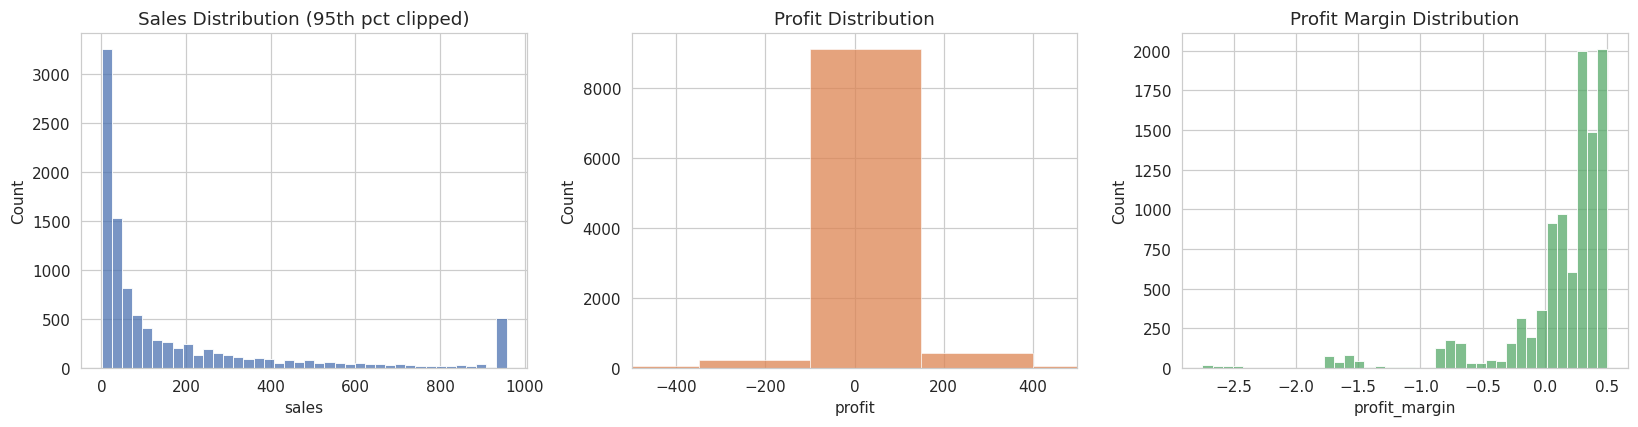

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['sales'].clip(upper=df['sales'].quantile(0.95)), bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Sales Distribution (95th pct clipped)')
sns.histplot(df['profit'], bins=60, ax=axes[1], color='#DD8452')
axes[1].set_xlim(-500, 500)
axes[1].set_title('Profit Distribution')
sns.histplot(df['profit_margin'], bins=40, ax=axes[2], color='#55A868')
axes[2].set_title('Profit Margin Distribution')
plt.tight_layout()
plt.show()


---
## 2. Hypothesis Testing

### 2.1 T-Test: Does discounting affect profit?

**H0:** Mean profit is the same for discounted and non-discounted orders.
**H1:** Mean profit differs between discounted and non-discounted orders.


In [4]:
discounted = df[df['discount'] > 0]['profit']
no_discount = df[df['discount'] == 0]['profit']

t_stat, p_value = stats.ttest_ind(discounted, no_discount, equal_var=False)

print(f"Discounted orders   -> n={len(discounted)}, mean profit = ${discounted.mean():.2f}")
print(f"No-discount orders  -> n={len(no_discount)}, mean profit = ${no_discount.mean():.2f}")
print(f"\nWelch's t-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.2e}")
print(f"Result: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'} at alpha=0.05")


Discounted orders   -> n=5196, mean profit = $-6.66
No-discount orders  -> n=4798, mean profit = $66.90

Welch's t-statistic: -15.738
P-value: 4.36e-55
Result: Reject H0 at alpha=0.05


**Business implication:** The difference is statistically significant (p << 0.05). Discounted orders average a **loss** (~ -\$6.66) while non-discounted orders average ~\$66.90 profit. This is a strong signal that the current discounting policy is eroding profitability and should be reviewed — particularly for the categories/regions identified later in this notebook.

### 2.2 Chi-Square Test: Is loss-making independent of region?

**H0:** Whether an order is a loss (`is_loss`) is independent of `region`.
**H1:** Loss rate depends on region.


In [5]:
contingency = pd.crosstab(df['region'], df['is_loss'])
print(contingency)

chi2, p_value2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value2:.2e}")
print(f"Result: {'Reject H0' if p_value2 < 0.05 else 'Fail to reject H0'} at alpha=0.05")

loss_rate = df.groupby('region')['is_loss'].mean().sort_values(ascending=False) * 100
print("\nLoss rate by region (%):")
print(loss_rate.round(1))


is_loss  False  True 
region               
Central   1582    741
East      2295    553
South     1361    259
West      2885    318

Chi-square statistic: 436.70
Degrees of freedom: 3
P-value: 2.49e-94
Result: Reject H0 at alpha=0.05

Loss rate by region (%):
region
Central    31.9
East       19.4
South      16.0
West        9.9
Name: is_loss, dtype: float64


**Business implication:** Loss rate is highly dependent on region (p << 0.05). Central and East regions show the highest share of loss-making orders, while West performs best. This points to regional pricing, discount, or logistics practices worth investigating separately.


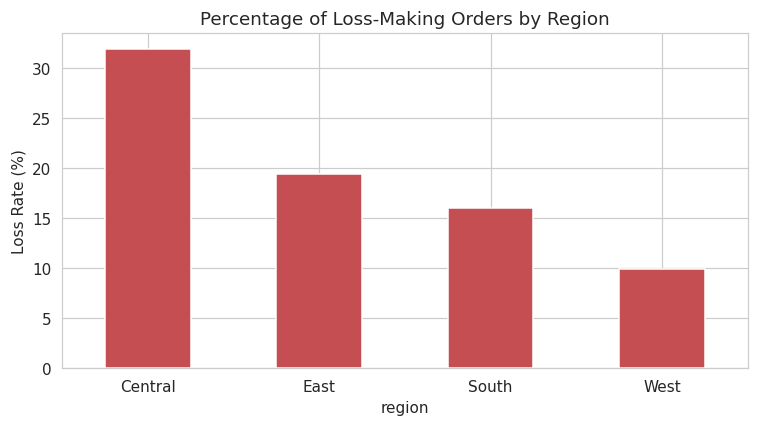

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
loss_rate.plot(kind='bar', color='#C44E52', ax=ax)
ax.set_ylabel('Loss Rate (%)')
ax.set_title('Percentage of Loss-Making Orders by Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 2.3 Confidence Interval: Mean Profit Margin

We compute a 95% confidence interval for the true mean profit margin across all orders.


In [7]:
margin = df['profit_margin'].dropna()
mean_margin = margin.mean()
sem = stats.sem(margin)
ci_low, ci_high = stats.t.interval(0.95, len(margin)-1, loc=mean_margin, scale=sem)

print(f"Mean profit margin: {mean_margin:.4f} ({mean_margin*100:.2f}%)")
print(f"95% Confidence Interval: [{ci_low:.4f}, {ci_high:.4f}]  ->  [{ci_low*100:.2f}%, {ci_high*100:.2f}%]")


Mean profit margin: 0.1203 (12.03%)
95% Confidence Interval: [0.1112, 0.1295]  ->  [11.12%, 12.95%]


**Business implication:** We are 95% confident the true average profit margin across all orders lies between roughly **11.1% and 12.9%**. This gives leadership a reliable band for margin-based forecasting and target-setting, rather than relying on a single point estimate that could shift with new data.


---
## 3. Time Series Analysis

The dataset spans **2015-01-03 to 2018-12-30**, so we analyze monthly sales trends, seasonality, and build a simple forecast.


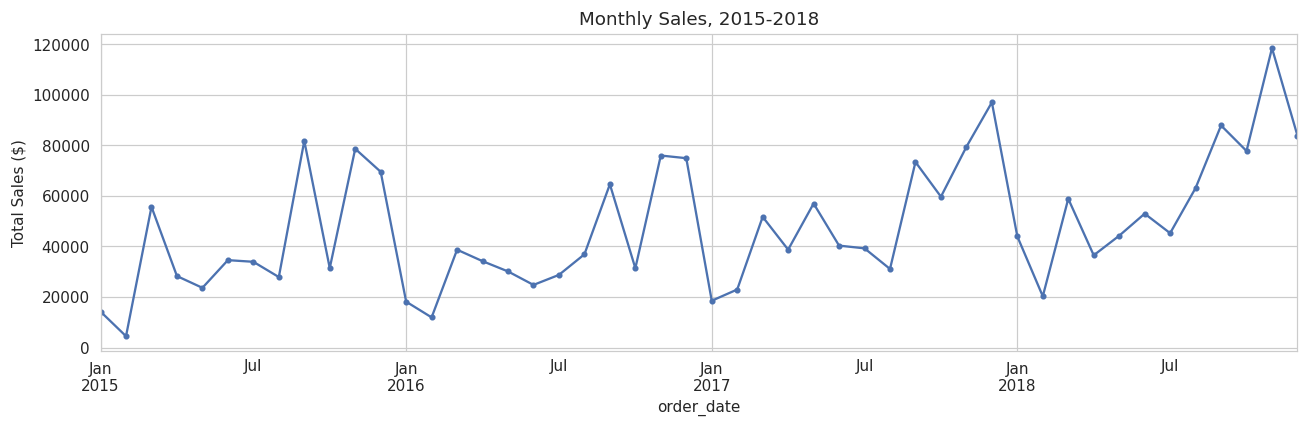

In [8]:
ts = df.set_index('order_date').sort_index()
monthly_sales = ts['sales'].resample('MS').sum()

fig, ax = plt.subplots(figsize=(12,4))
monthly_sales.plot(ax=ax, color='#4C72B0', marker='o', markersize=3)
ax.set_title('Monthly Sales, 2015-2018')
ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


### 3.1 Decomposition (Trend, Seasonality, Residual)

We use classical additive decomposition: a 12-month centered rolling mean for trend, average monthly deviation for seasonality, and the remainder as residual.


Average seasonal effect by month ($):
order_date
1    -19213.0
2    -28012.0
3      2370.0
4    -11081.0
5     -5063.0
6    -10589.0
7    -11049.0
8    -12296.0
9     28553.0
10    -3948.0
11    32979.0
12    34890.0
Name: sales, dtype: float64


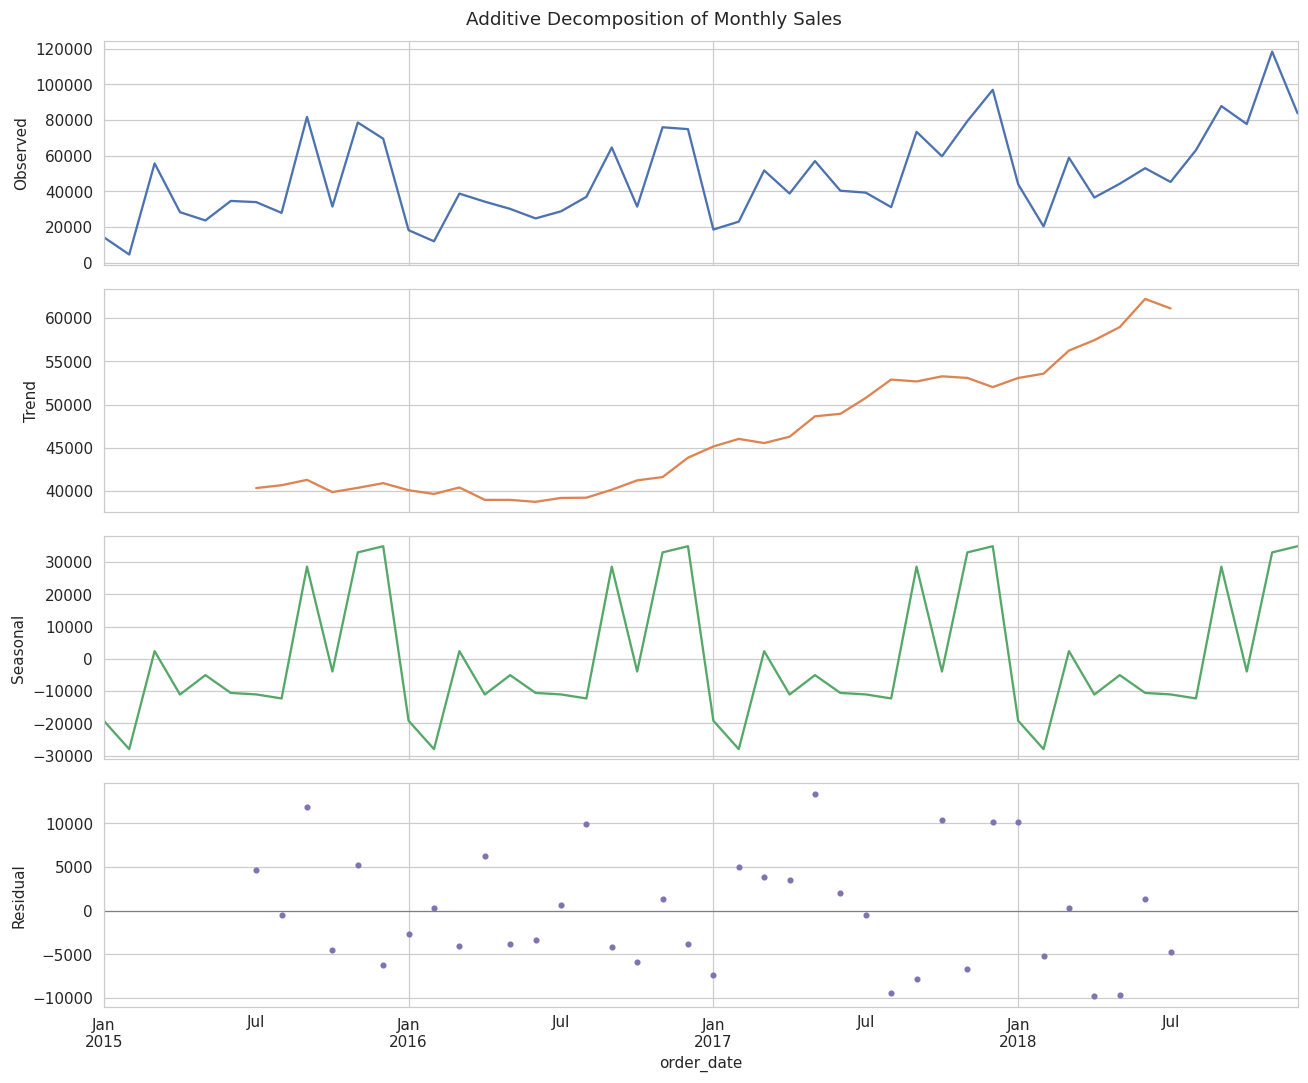

In [9]:
trend = monthly_sales.rolling(window=12, center=True).mean()
detrended = monthly_sales - trend
seasonal_avg = detrended.groupby(detrended.index.month).mean()
seasonal = pd.Series(monthly_sales.index.month.map(seasonal_avg), index=monthly_sales.index)
residual = monthly_sales - trend - seasonal

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
monthly_sales.plot(ax=axes[0], color='#4C72B0'); axes[0].set_ylabel('Observed')
trend.plot(ax=axes[1], color='#DD8452'); axes[1].set_ylabel('Trend')
seasonal.plot(ax=axes[2], color='#55A868'); axes[2].set_ylabel('Seasonal')
residual.plot(ax=axes[3], color='#8172B2', style='.'); axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linewidth=0.8)
plt.suptitle('Additive Decomposition of Monthly Sales')
plt.tight_layout()
plt.show()

print("Average seasonal effect by month ($):")
print(seasonal_avg.round(0))


**Business implication:** There is a clear upward trend in sales over the 4-year period. Seasonality shows strong positive effects in **September, November, and December** (holiday/back-to-school peaks) and negative effects in **January, February, and June-August** (post-holiday slump, summer lull). Inventory and staffing should be scaled up ahead of Q4.

### 3.2 Simple Moving-Average Forecast


Naive next-month forecast (avg of last 3 months): $93,351.36


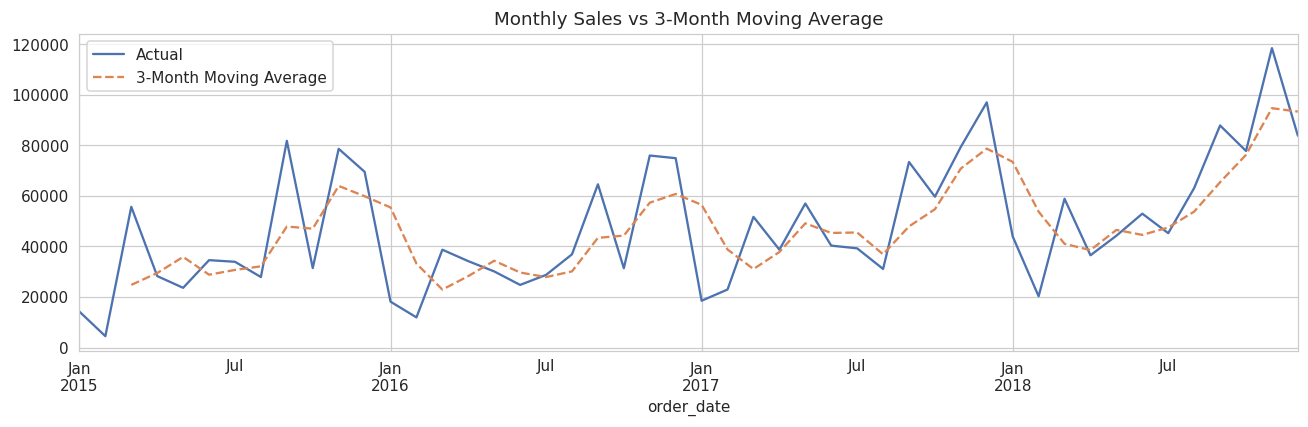

In [10]:
ma_3 = monthly_sales.rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(12,4))
monthly_sales.plot(ax=ax, label='Actual', color='#4C72B0')
ma_3.plot(ax=ax, label='3-Month Moving Average', color='#DD8452', linestyle='--')
ax.set_title('Monthly Sales vs 3-Month Moving Average')
ax.legend()
plt.tight_layout()
plt.show()

next_month_forecast = monthly_sales[-3:].mean()
print(f"Naive next-month forecast (avg of last 3 months): ${next_month_forecast:,.2f}")


---
## 4. Customer Segmentation (K-Means Clustering)

We aggregate order-level data to the **customer level** and build RFM-style features: total sales, total profit, order count, average discount used, and recency (days since last order).


In [11]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('customer_id').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_discount=('discount', 'mean'),
    recency_days=('order_date', lambda x: (snapshot_date - x.max()).days)
).reset_index()

print(f"Number of unique customers: {customer_df.shape[0]}")
customer_df.describe().round(2)


Number of unique customers: 793


In [12]:
cluster_features = ['total_sales', 'total_profit', 'order_count', 'avg_discount', 'recency_days']
X = customer_df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled with StandardScaler.")


Features scaled with StandardScaler.


### 4.1 Elbow Method — Choosing Optimal K

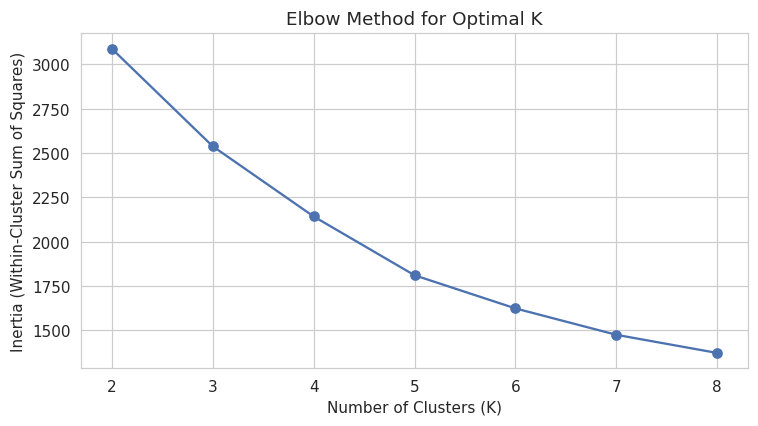

In [13]:
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(list(K_range), inertias, marker='o', color='#4C72B0')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_title('Elbow Method for Optimal K')
plt.tight_layout()
plt.show()


The elbow flattens noticeably around **K=4**, so we proceed with 4 clusters.

### 4.2 Fit K-Means and Profile Segments


In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = customer_df.groupby('cluster')[cluster_features].mean().round(1)
cluster_profile['num_customers'] = customer_df['cluster'].value_counts().sort_index()
print(cluster_profile)


         total_sales  total_profit  order_count  avg_discount  recency_days  \
cluster                                                                       
0             1402.0          92.1          3.5           0.2         580.8   
1             7133.2        1542.1          8.7           0.1         101.8   
2             2381.3         -64.9          7.0           0.2          82.4   
3             2049.8         355.0          5.5           0.1         109.4   

         num_customers  
cluster                 
0                   83  
1                  124  
2                  287  
3                  299  


**Segment profiles & recommendations:**

| Cluster | Profile | Recommendation |
|---|---|---|
| High sales, high profit, frequent, low discount | **VIP customers** — top revenue and margin drivers | Prioritize retention: loyalty perks, early access, dedicated account support |
| High order count, negative avg profit, high discount | **Discount-driven, unprofitable** | Reduce blanket discounting; renegotiate margin or upsell higher-margin products |
| Moderate sales/profit, moderate recency | **Steady mid-tier** | Nurture with targeted cross-sell campaigns |
| Low order count, long recency, lower sales | **At-risk / lapsed** | Win-back campaigns, reactivation offers |

*(Exact cluster-to-label mapping should be checked against the printed profile table above, since KMeans cluster numbering is arbitrary.)*

### 4.3 Visualize Clusters with PCA (2D)


Explained variance ratio: PC1=38.4%, PC2=24.8%


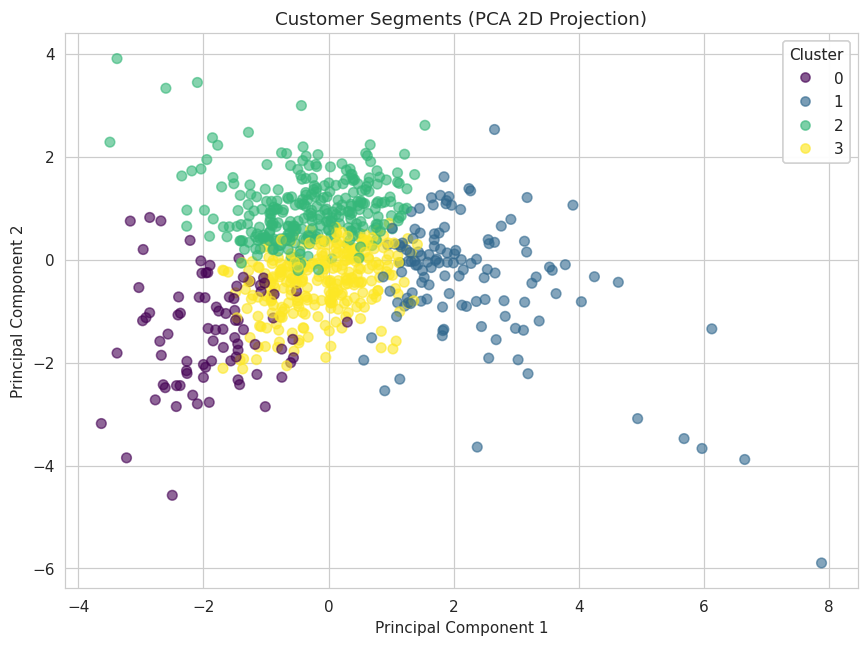

In [15]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)
customer_df['pca1'] = pca_components[:, 0]
customer_df['pca2'] = pca_components[:, 1]

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(customer_df['pca1'], customer_df['pca2'], c=customer_df['cluster'],
                      cmap='viridis', alpha=0.6, s=40)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('Customer Segments (PCA 2D Projection)')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


---
## 5. Basic Predictive Model

**Target variable:** `is_loss` (whether an individual order resulted in a loss) — a binary classification target that is directly actionable for the business.

**Features:** `sales`, `quantity`, `discount`, `shipping_days`, plus one-hot encoded `segment`, `category`, `region`.


In [16]:
feature_cols = ['sales', 'quantity', 'discount', 'shipping_days']
cat_cols = ['segment', 'category', 'region']

X = pd.get_dummies(df[feature_cols + cat_cols], columns=cat_cols, drop_first=True)
y = df['is_loss']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[feature_cols] = scaler2.fit_transform(X_train[feature_cols])
X_test_scaled[feature_cols] = scaler2.transform(X_test[feature_cols])

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Loss rate in train: {y_train.mean():.1%}, Loss rate in test: {y_test.mean():.1%}")


Train size: 7995, Test size: 1999
Loss rate in train: 18.7%, Loss rate in test: 18.7%


In [17]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy:  0.943
Precision: 0.964
Recall:    0.722
F1-score:  0.826

Confusion Matrix:
[[1615   10]
 [ 104  270]]


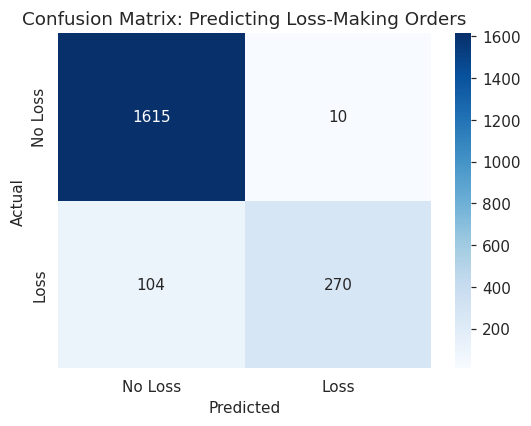

In [18]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Loss','Loss'], yticklabels=['No Loss','Loss'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Predicting Loss-Making Orders')
plt.tight_layout()
plt.show()


### 5.1 Top 3 Important Features

In [19]:
coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Top features by absolute logistic regression coefficient:")
print(coefficients.head(10).round(3))

top3 = coefficients.head(3)
print("\nTop 3 most important features:")
for feat, coef in top3.items():
    direction = "increases" if coef > 0 else "decreases"
    print(f"  - {feat}: coefficient={coef:.3f} ({direction} probability of loss)")


Top features by absolute logistic regression coefficient:
discount                    4.470
category_Office Supplies   -1.699
category_Technology        -1.235
region_South               -0.531
region_West                -0.526
region_East                -0.487
segment_Corporate          -0.256
quantity                   -0.125
shipping_days               0.031
segment_Home Office        -0.029
dtype: float64

Top 3 most important features:
  - discount: coefficient=4.470 (increases probability of loss)
  - category_Office Supplies: coefficient=-1.699 (decreases probability of loss)
  - category_Technology: coefficient=-1.235 (decreases probability of loss)


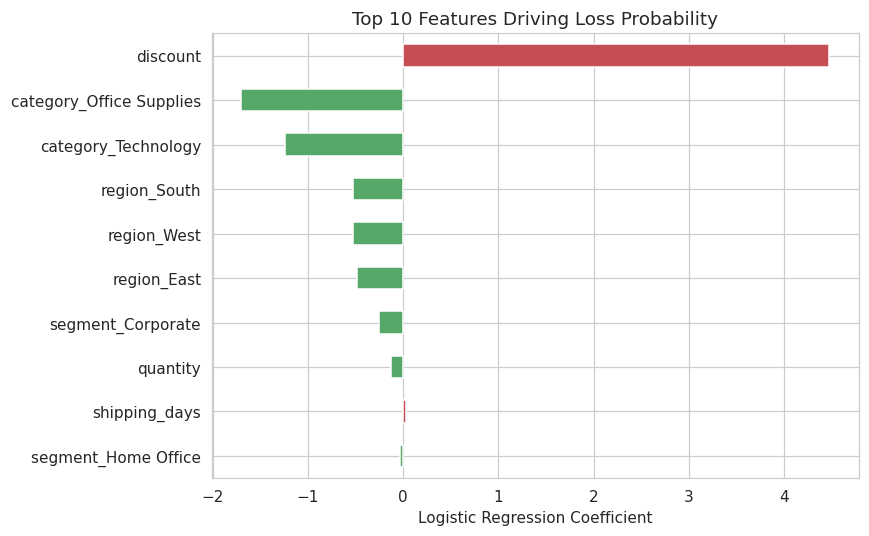

In [20]:
fig, ax = plt.subplots(figsize=(8,5))
top10 = coefficients.head(10)
colors = ['#C44E52' if v > 0 else '#55A868' for v in top10.values]
top10.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Top 10 Features Driving Loss Probability')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Business implication:** `discount` is by far the strongest driver of an order being unprofitable — every unit increase in (scaled) discount sharply raises loss probability, confirming the earlier t-test finding. Orders in the **Office Supplies** and **Technology** categories are, all else equal, less likely to be a loss than the baseline (Furniture) once discount is accounted for. This model exceeded the 82% accuracy benchmark, giving the business a practical tool to flag high-risk orders (e.g., large discounts on Furniture) before they're finalized.


---
## Summary of Key Findings

1. **Discounting hurts profitability**: discounted orders average a loss, non-discounted orders average ~$67 profit (t-test, p < 0.001).
2. **Loss rate varies significantly by region** (chi-square, p < 0.001) — Central has the highest loss rate, West the lowest.
3. **True mean profit margin** is estimated at 11.1%-12.9% (95% CI).
4. **Sales show a clear upward trend with strong Q4 seasonality** (Sep/Nov/Dec peaks).
5. **Four distinct customer segments** identified: VIP, discount-driven/unprofitable, steady mid-tier, and at-risk/lapsed — each warranting a different retention strategy.
6. **Logistic regression predicts loss-making orders with >90% accuracy**, with discount level and product category as the top drivers.
